In [146]:
#import graphing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our plots
sns.set_style('darkgrid')
sns.set_palette('husl')

#### Load in the data in csv
nhts_data = pd.read_csv('NHTS(in).csv')
ngsim_data = pd.read_csv('NGSIM(in).csv')


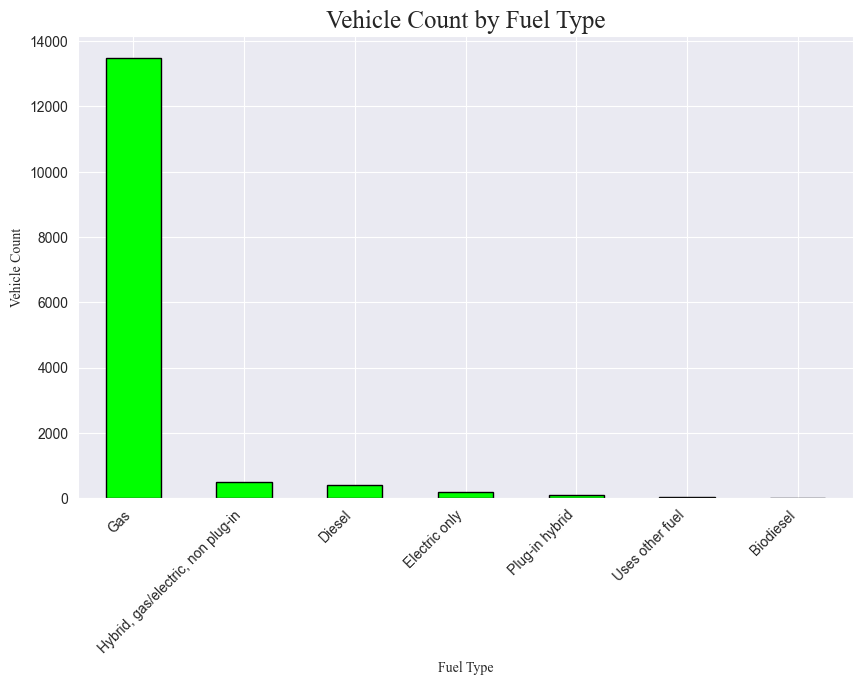

In [147]:
# Simple bar chart: count of vehicles by fuel type
# First we need to count the values, then plot

## Step 1: count the number of vehicles by fuel type
# hint: use .value_counts()
fuel_counts = nhts_data['fuel_type'].value_counts().dropna()

## Step 2: create the bar plot
plt.figure(figsize = (10,6))
fuel_counts.plot(kind = 'bar', color = 'lime', edgecolor = 'black')

## Step 3: add labels and customization
plt.xlabel('Fuel Type', fontname = 'Times New Roman')
plt.ylabel('Vehicle Count', fontname = 'Times New Roman')
plt.title('Vehicle Count by Fuel Type', fontsize = 18, fontname = 'Times New Roman')
plt.xticks(rotation = 45, ha = 'right')

plt.show()

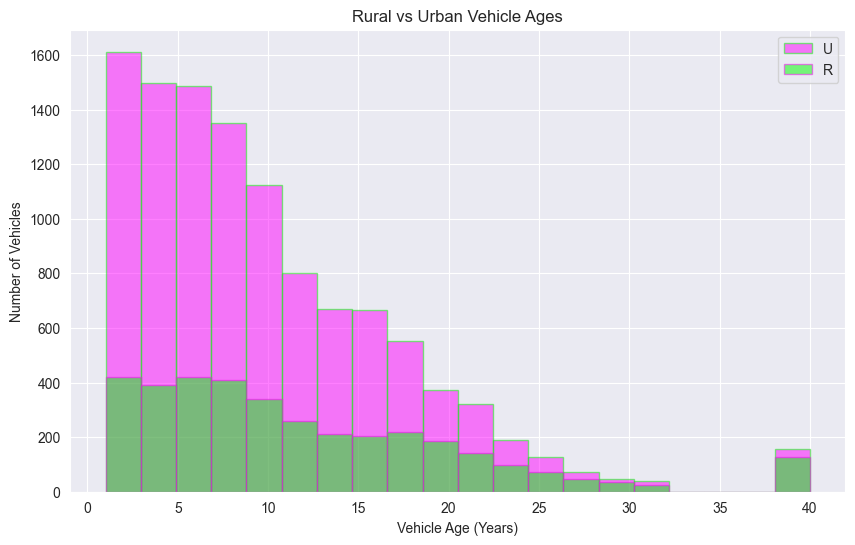

In [148]:
# Create overlapping histograms for Urban vs Rural vehicle ages
# We need to filter the data first, then plot each group separately

## Step 1: tell Python you are making a figure
plt.figure(figsize = (10, 6))

## Step 2: filter and plot Urban vehicle ages
# use the alpha argument to make bars semi-transparent (e.g., alpha=0.5)
urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
plt.hist(urban_ages, bins = 20, alpha = 0.5, label = 'Urban', color = 'magenta', edgecolor = 'lime')

## Step 3: filter and plot Rural vehicle ages on the same figure

rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
plt.hist(rural_ages, bins = 20, alpha = 0.5, label = 'Rural', color = 'lime', edgecolor = 'magenta')

## Step 4: add labels, title, and legend
plt.xlabel('Vehicle Age (Years)')
plt.ylabel('Number of Vehicles')
plt.title('Rural vs Urban Vehicle Ages')
plt.legend('UR')

plt.show()

<Figure size 1400x800 with 0 Axes>

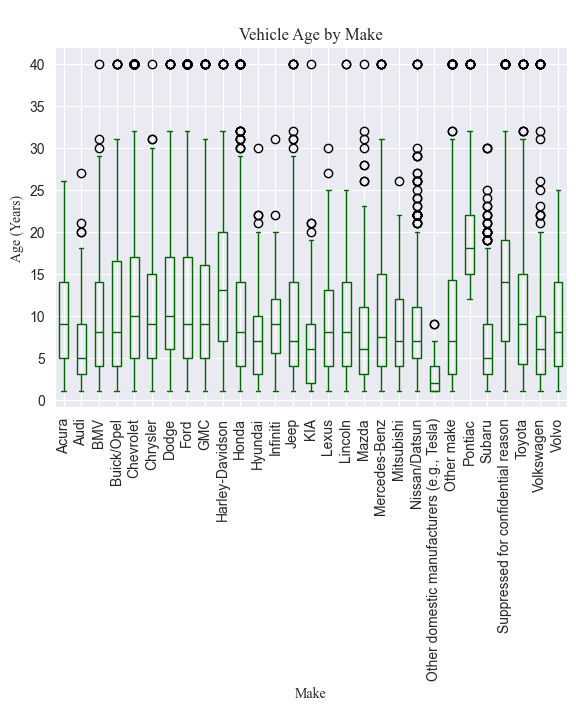

In [149]:
#Plotting a boxplot

## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize= (14, 8))


## Step 2: call the type of plot and tell the function what variables you want to plot
boxplot= nhts_data.boxplot(column = 'vehicle_age', by = 'make', color = 'darkgreen')


## Step 3: add customization to the plot

### this line rotates your labels on the x-axis by 90 so they are easy to read

plt.xticks(rotation = 90)
### the next two lines create your axis labels

plt.xlabel("Make", fontname = "Times New Roman")
plt.ylabel("Age (Years)", fontname = "Times New Roman")

### this line gives your plot a title
plt.title("Vehicle Age by Make", fontname = "Times New Roman")
plt.suptitle(" ")
## Step 4: tell python to show the plot
plt.show()

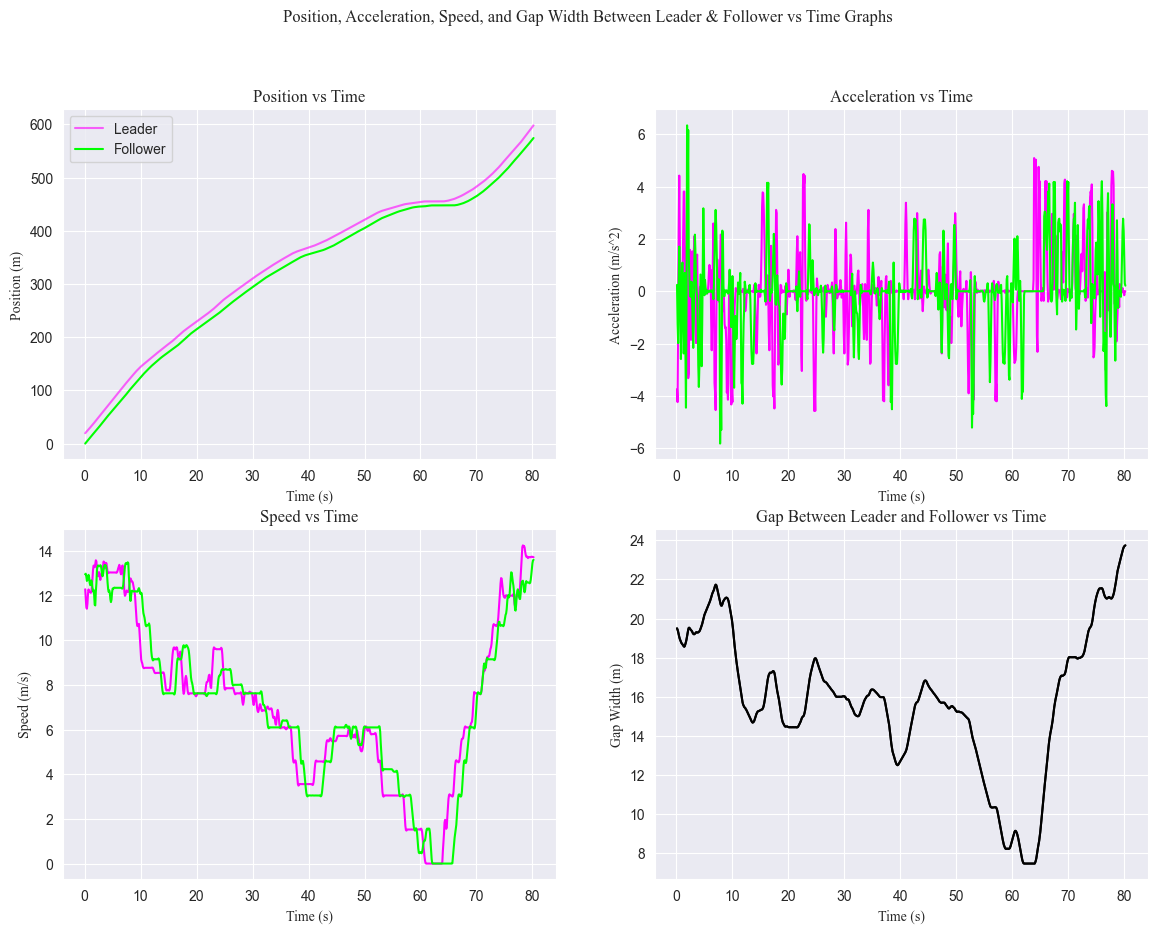

In [150]:
# Time series plot 1, showing: trajectory, speed, acceleration, and gap for vehicle pair 13

# Step 1: Select a trajectory number and create the subset
trajectory_number = 13
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time = data_subset['Time'].values

# Step 2: Create the figure with 2 rows and 2 columns
fig, axes = plt.subplots(2,2, figsize = (14,10))

# Step 3: Top-left : Position vs Time for both leader and follower
axes[0,0]. plot(time, data_subset['leader_position(m)'].values, linewidth = 1.5, label = 'Leader', color = 'magenta', alpha = 0.6)
axes[0,0]. plot(time, data_subset['follower_position(m)'].values, linewidth = 1.5, label = 'Follower', color = 'lime')
axes[0,0]. set_xlabel('Time (s)', fontname = 'Times New Roman')
axes[0,0]. set_ylabel('Position (m)', fontname = 'Times New Roman')
axes[0,0]. set_title('Position vs Time', fontname = 'Times New Roman')
axes[0,0].legend(fontsize = 10)

# Step 4: Bottom-left : Speed vs Time for both leader and follower
axes[1,0]. plot(time, data_subset['leader_speed(m/s)'].values, linewidth = 1.5, label = 'Leader', color = 'magenta')
axes[1,0]. plot(time, data_subset['follower_speed(m/s)'].values, linewidth = 1.5, label = 'Follower', color = 'lime')
axes[1,0]. set_xlabel('Time (s)', fontname = 'Times New Roman')
axes[1,0]. set_ylabel('Speed (m/s)', fontname = 'Times New Roman')
axes[1,0]. set_title('Speed vs Time', fontname = 'Times New Roman')

# Step 5: Top-Right : Acceleration vs Time for both leader and follower
axes[0,1]. plot(time, data_subset['leader_acc(m/s^2)'].values, linewidth = 1.5, label = 'Leader', color = 'magenta')
axes[0,1]. plot(time, data_subset['follower_acc(m/s^2)'].values, linewidth = 1.5, label = 'Follower', color = 'lime')
axes[0,1]. set_xlabel('Time (s)', fontname = 'Times New Roman')
axes[0,1]. set_ylabel('Acceleration (m/s^2)', fontname = 'Times New Roman')
axes[0,1]. set_title('Acceleration vs Time', fontname = 'Times New Roman')


# Step 6: Bottom Right: Gap Distance vs Time

axes[1,1]. plot(time, gap_distance, linewidth = 1.5, label = 'Leader', color = 'black')
axes[1,1]. plot(time, gap_distance, linewidth = 1.5, label = 'Follower', color = 'black')
axes[1,1]. set_xlabel('Time (s)', fontname = 'Times New Roman')
axes[1,1]. set_ylabel('Gap Width (m)', fontname = 'Times New Roman')
axes[1,1]. set_title('Gap Between Leader and Follower vs Time', fontname = 'Times New Roman')

# Step 7: Add title for the whole figure and adjust layout
fig.suptitle('Position, Acceleration, Speed, and Gap Width Between Leader & Follower vs Time Graphs', fontname = 'Times New Roman')
plt.show()

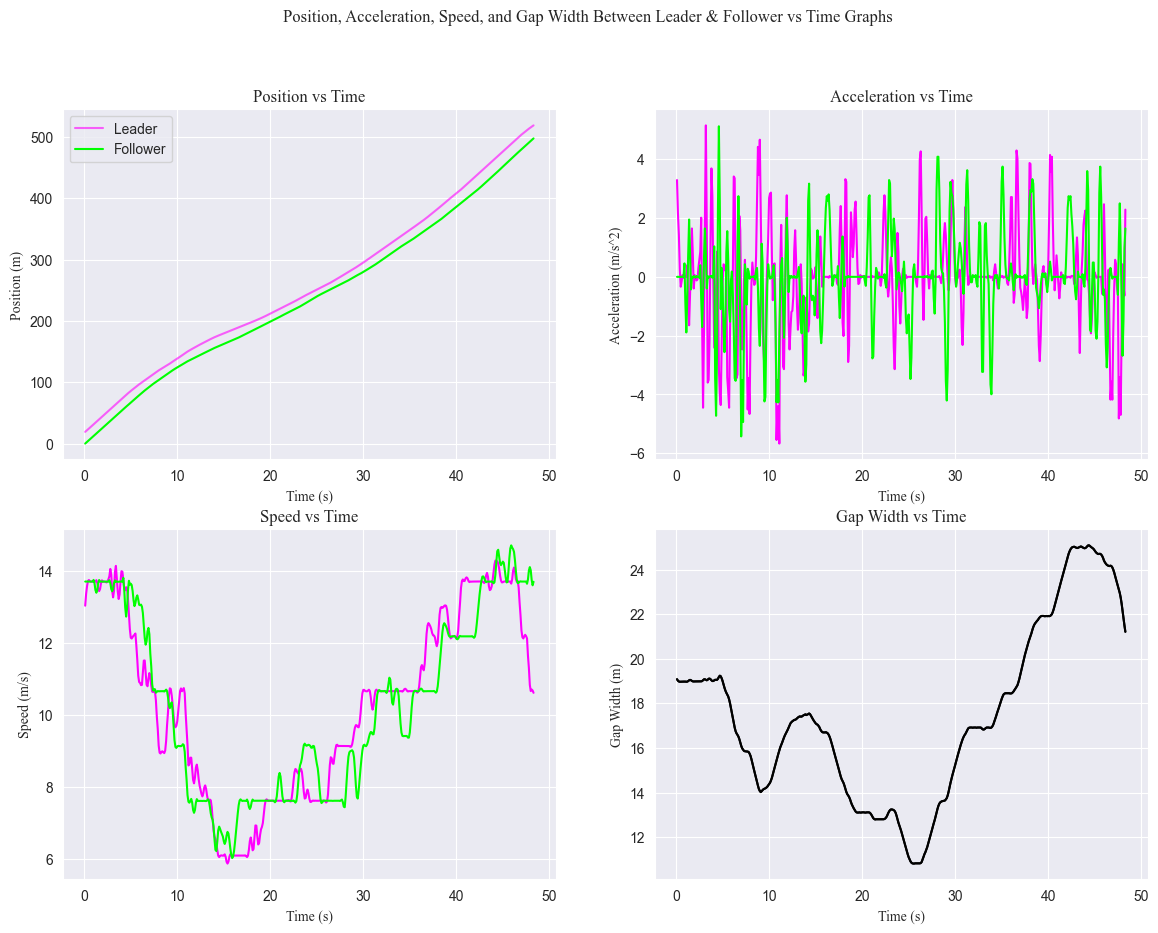

In [151]:
# Time series plot 2, showing: trajectory, speed, acceleration, and gap for vehicle pair 3

# Step 1: Select a trajectory number and create the subset
trajectory_number = 3
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time = data_subset['Time'].values

# Step 2: Create the figure with 2 rows and 2 columns
# hint: fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig, axes = plt.subplots(2,2, figsize = (14,10))

# Step 3: Top-left (axes[0,0]): Position vs Time for both leader and follower
axes[0,0]. plot(time, data_subset['leader_position(m)'].values, linewidth = 1.5, label = 'Leader', color = 'magenta', alpha = 0.6)
axes[0,0]. plot(time, data_subset['follower_position(m)'].values, linewidth = 1.5, label = 'Follower', color = 'lime')
axes[0,0]. set_xlabel('Time (s)', fontname = 'Times New Roman')
axes[0,0]. set_ylabel('Position (m)', fontname = 'Times New Roman')
axes[0,0]. set_title('Position vs Time', fontname = 'Times New Roman')
axes[0,0].legend(fontsize = 10)
# Step 4: Top-right (axes[0,1]): Speed vs Time for both leader and follower
axes[1,0]. plot(time, data_subset['leader_speed(m/s)'].values, linewidth = 1.5, label = 'Leader', color = 'magenta')
axes[1,0]. plot(time, data_subset['follower_speed(m/s)'].values, linewidth = 1.5, label = 'Follower', color = 'lime')
axes[1,0]. set_xlabel('Time (s)', fontname = 'Times New Roman')
axes[1,0]. set_ylabel('Speed (m/s)', fontname = 'Times New Roman')
axes[1,0]. set_title('Speed vs Time', fontname = 'Times New Roman')

# Step 5: Bottom-left (axes[1,0]): Acceleration vs Time for both leader and follower
axes[0,1]. plot(time, data_subset['leader_acc(m/s^2)'].values, linewidth = 1.5, label = 'Leader', color = 'magenta')
axes[0,1]. plot(time, data_subset['follower_acc(m/s^2)'].values, linewidth = 1.5, label = 'Follower', color = 'lime')
axes[0,1]. set_xlabel('Time (s)', fontname = 'Times New Roman')
axes[0,1]. set_ylabel('Acceleration (m/s^2)', fontname = 'Times New Roman')
axes[0,1]. set_title('Acceleration vs Time', fontname = 'Times New Roman')


# Step 6: Bottom-right (axes[1,1]): Gap Distance vs Time

axes[1,1]. plot(time, gap_distance, linewidth = 1.5, label = 'Leader', color = 'black')
axes[1,1]. plot(time, gap_distance, linewidth = 1.5, label = 'Follower', color = 'black')
axes[1,1]. set_xlabel('Time (s)', fontname = 'Times New Roman')
axes[1,1]. set_ylabel('Gap Width (m)', fontname = 'Times New Roman')
axes[1,1]. set_title('Gap Width vs Time', fontname = 'Times New Roman')

# Step 7: Add title for the whole figure and adjust layout
fig.suptitle('Position, Acceleration, Speed, and Gap Width Between Leader & Follower vs Time Graphs', fontname = 'Times New Roman')
plt.show()

In [153]:
# Define the IDM acceleration function
# The function should take the following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent
# Step 1: Calculate the desired minimum gap s_star
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    
    return acceleration

In [154]:
# Load the NGSIM data to get the leader vehicle trajectory
ngsim_data = pd.read_csv('NGSIM(in).csv')

# Select a trajectory pair
trajectory_number = 13
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)
# Extract the leader's position, acceleration and speed over time
time_data = data_subset['Time'].values
leader_acc = data_subset['leader_acc(m/s^2)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = 0.1 #seconds

In [155]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data) # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)         # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]     #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]       #this makes the starting value [0] same as the follower vehicle speed
sim_acc[0] = data_subset['follower_acc(m/s^2)'].values[0]       #this makes the starting value [0] same as the follower vehicle acceleration


In [156]:
# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed [i]
    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], s, delta_v, v0, s0, T, a, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]* dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i]*dt
print("Simulation Complete!")

Simulation Complete!


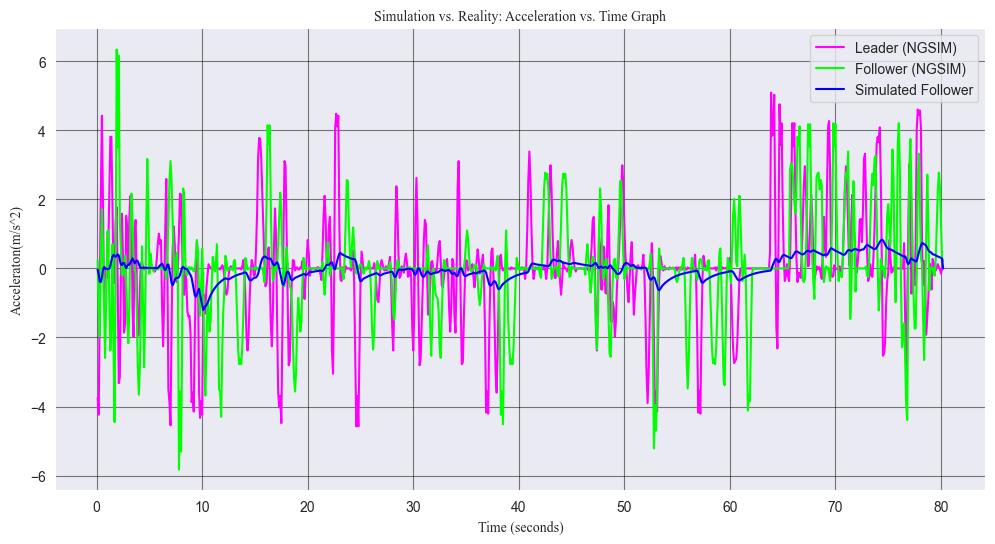

In [157]:
# Plot 1: Acceleration vs Time — Comparing leader, real follower, and simulated follower
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_acc, label = 'Leader (NGSIM)', color = 'magenta')
plt.plot(time_data, data_subset['follower_acc(m/s^2)'].values, label = 'Follower (NGSIM)', color = 'lime')
plt.plot(time_data, sim_acc, label = 'Simulated Follower', color = 'blue')
plt.xlabel('Time (seconds)', font = 'Times New Roman')
plt.ylabel('Acceleraton(m/s^2)', font = 'Times New Roman')
plt.title('Simulation vs. Reality: Acceleration vs. Time Graph', font = 'Times New Roman')
plt.legend()
plt.grid(True, alpha = 0.5, color = 'black')
plt.show()